# Computational Causality Analysis

- System is built up of modules
- Modules may have input, output, and state variables
- Connections are esatblished by defining which output variables of a source module are fed to input ports of destination modules
- A feedback loop is created when
    - an output variable of a module is connected to an input port of a module
    - the module also has an output port that is connected to that module
    - the involved variables are directly dependent

In [236]:
import networkx as nx
from pint import Quantity, UnitRegistry

ureg = UnitRegistry()
ureg.formatter.default_format = "~P"

In [237]:
class Variable:
    name: str = "Variable"
    quantity: Quantity = Quantity(0.0, "")

    def __init__(self, name: str, value, unit):
        self.name = name
        self.quantity = value * ureg(unit)

In [238]:
class Module:
    name: str = "Module"
    inputs: dict[str, Variable] = {}
    outputs: dict[str, Variable] = {}
    group: str = ""
    label: str = ""

    def __init__(self, name: str, group: str = ""):
        self.name = name
        self.group = group
        self.inputs = {}
        self.outputs = {}
        pass

    def add_input(self, var: Variable):
        self.inputs[var.name] = var

    def add_output(self, var: Variable):
        self.outputs[var.name] = var

    def set_input(self, name: str, value: float):
        self.inputs[name].quantity = value

    def get_output(self, name: str) -> float:
        return self.outputs[name].quantity

    def do_step(self):
        for out_var in self.outputs.keys():
            self.outputs[out_var].quantity += 1 * self.outputs[out_var].quantity.units

    def reset(self):
        for in_var, out_var in zip(self.outputs.keys(), self.inputs.keys()):
            self.inputs[in_var] = 0
            self.outputs[out_var] = 0

    def _build_label(self):
        in_str = "{ " + " | ".join(f"<{name}> {name}" for name in self.inputs.keys()) + " }"
        out_str = "{ " + " | ".join(f"<{name}> {name}" for name in self.outputs.keys()) + " }"
        if in_str == "{  }":
            in_str = ""
        if out_str == "{  }":
            out_str = ""
        if in_str and out_str:
            self.label = f"{{ {in_str} | {self.name} | {out_str} }}"
        elif in_str:
            self.label = f"{{ {in_str} | {self.name} }}"
        elif out_str:
            self.label = f"{{ {self.name} | {out_str} }}"
        else:
            self.label = f"{self.name}"

- Delay is used to break algebraic loops
- If variables from a previous time step are used as module inputs for this connection

In [239]:
class Connection:
    src_module: Module
    src_out_port: Variable
    dst_module: Module
    dst_in_port: Variable
    delay: int = 0

    def __init__(
        self,
        src_module: Module,
        src_out_port: Variable,
        dst_module: Module,
        dst_in_port: Variable,
        delay=0,
    ):
        # Check unit compatibility
        if not src_out_port.quantity.is_compatible_with(dst_in_port.quantity):
            raise ValueError(
                f"Unit mismatch: {src_out_port.quantity.unit_items()} (source) is not compatible with {dst_in_port.quantity.unit_items()} (destination)"
            )
        self.src_module = src_module
        self.src_out_port = src_out_port
        self.dst_module = dst_module
        self.dst_in_port = dst_in_port
        self.delay = delay

In [240]:
# Create Variables
q_ref = Variable(name="q_ref", value=0, unit="rad")
q_state = Variable(name="q_state", value=0, unit="rad")
Uq_ref = Variable(name="Uq_ref", value=0, unit="V")
Uq_state = Variable(name="Uq_state", value=0, unit="V")
u_control = Variable(name="u_control", value=0, unit="")
torque = Variable(name="torque", value=0, unit="Nm")
omega = Variable(name="omega", value=0, unit="rad/s")

In [241]:
# Create Modules
mod_ref = Module(name="Reference", group="Input")
mod_ref.add_output(q_ref)
mod_ref._build_label()

mod_sensor_ref = Module(name="SensorRef", group="Sensors")
mod_sensor_ref.add_input(q_ref)
mod_sensor_ref.add_output(Uq_ref)
mod_sensor_ref._build_label()

mod_sensor_state = Module(name="SensorState", group="Sensors")
mod_sensor_state.add_input(q_state)
mod_sensor_state.add_output(Uq_state)
mod_sensor_state._build_label()

mod_controller = Module(name="Controller", group="Control")
mod_controller.add_input(Uq_ref)
mod_controller.add_input(Uq_state)
mod_controller.add_output(u_control)
mod_controller._build_label()

mod_drive = Module(name="Drive", group="Actuator")
mod_drive.add_input(u_control)
mod_drive.add_input(omega)
mod_drive.add_output(torque)
mod_drive._build_label()

mod_pendulum = Module(name="Pendulum", group="Plant")
mod_pendulum.add_input(torque)
mod_pendulum.add_output(q_state)
mod_pendulum.add_output(omega)
mod_pendulum._build_label()

modules = [mod_ref, mod_sensor_ref, mod_sensor_state, mod_controller, mod_drive, mod_pendulum]

In [242]:
class System:
    name: str = "System"
    modules: dict[str, Module] = {}
    connections: list[Connection] = []
    graph: nx.MultiDiGraph
    groups: dict[str, list[Module]] = {}

    def __init__(self, name: str):
        self.name = name
        self.modules = {}
        self.connections = []
        self.graph = nx.MultiDiGraph()
        pass

    def add_module(self, module: Module):
        self.modules[module.name] = module
        self.graph.add_node(module.name)
        if module.group not in self.groups:
            self.groups[module.group] = []
        self.groups[module.group].append(module)

    def add_connection(self, c: Connection):
        self.connections.append(c)
        self.graph.add_edge(
            c.src_module.name,
            c.dst_module.name,
            src_port=c.src_out_port.name,
            dst_port=c.dst_in_port.name,
            delay=c.delay,
        )

In [243]:
system = System(name="Controlled Pendulum")

for mod in modules:
    system.add_module(mod)

In [244]:
import random

c1 = Connection(
    src_module=mod_ref,
    src_out_port=mod_ref.outputs["q_ref"],
    dst_module=mod_sensor_ref,
    dst_in_port=mod_sensor_ref.inputs["q_ref"],
)

c2 = Connection(
    src_module=mod_pendulum,
    src_out_port=mod_pendulum.outputs["q_state"],
    dst_module=mod_sensor_state,
    dst_in_port=mod_sensor_state.inputs["q_state"],
    delay=1,
)

c3 = Connection(
    src_module=mod_sensor_ref,
    src_out_port=mod_sensor_ref.outputs["Uq_ref"],
    dst_module=mod_controller,
    dst_in_port=mod_controller.inputs["Uq_ref"],
)

c4 = Connection(
    src_module=mod_sensor_state,
    src_out_port=mod_sensor_state.outputs["Uq_state"],
    dst_module=mod_controller,
    dst_in_port=mod_controller.inputs["Uq_state"],
)

c5 = Connection(
    src_module=mod_controller,
    src_out_port=mod_controller.outputs["u_control"],
    dst_module=mod_drive,
    dst_in_port=mod_drive.inputs["u_control"],
)

c6 = Connection(
    src_module=mod_drive,
    src_out_port=mod_drive.outputs["torque"],
    dst_module=mod_pendulum,
    dst_in_port=mod_pendulum.inputs["torque"],
)

c7 = Connection(
    src_module=mod_pendulum,
    src_out_port=mod_pendulum.outputs["omega"],
    dst_module=mod_drive,
    dst_in_port=mod_drive.inputs["omega"],
    delay=1,
)

connections = [c7, c6, c5, c4, c3, c2, c1]

random.shuffle(connections)

for conn in connections:
    system.add_connection(conn)

for e in system.graph.edges(data=True):
    src_mod, dst_mod, data = e
    src_p, dst_p, delay = data
    print(e)

('Reference', 'SensorRef', {'src_port': 'q_ref', 'dst_port': 'q_ref', 'delay': 0})
('SensorRef', 'Controller', {'src_port': 'Uq_ref', 'dst_port': 'Uq_ref', 'delay': 0})
('SensorState', 'Controller', {'src_port': 'Uq_state', 'dst_port': 'Uq_state', 'delay': 0})
('Controller', 'Drive', {'src_port': 'u_control', 'dst_port': 'u_control', 'delay': 0})
('Drive', 'Pendulum', {'src_port': 'torque', 'dst_port': 'torque', 'delay': 0})
('Pendulum', 'SensorState', {'src_port': 'q_state', 'dst_port': 'q_state', 'delay': 1})
('Pendulum', 'Drive', {'src_port': 'omega', 'dst_port': 'omega', 'delay': 1})


In [ ]:
import networkx as nx


def compute_execution_order(system: System):
    """
    Builds a directed acyclic graph (DAG) of zero-delay dependencies
    and computes a valid execution order.
    Modules connected by zero-delay edges must execute in the same tick
    in the order defined by the edges.
    Modules connected by one-delay edges can execute in any order
    in the next tick, as they do not have same-tick dependencies.
    Returns:
      - order_idx: dict[module_name -> int]  (0-based order)
      - generations: list[list[module_name]] (parallelizable layers)
    """
    dag = nx.DiGraph()
    dag.add_nodes_from(system.modules.keys())

    # Only zero-delay edges enforce same-tick ordering
    for c in system.connections:
        if c.delay == 0:
            dag.add_edge(c.src_module.name, c.dst_module.name)

    # Check for cycles; if present, report them so user can add delays
    if not nx.is_directed_acyclic_graph(dag):
        cycles = list(nx.simple_cycles(dag))
        raise RuntimeError(
            "Cycle(s) detected among zero-delay dependencies: "
            + "; ".join(" -> ".join(c) for c in cycles)
        )

    # Parallelizable generations (each inner list can run concurrently)
    gens = list(nx.topological_generations(dag))

    # Flatten to an index (stable order)
    order_idx = {}
    idx = 0
    for g in gens:
        for node in g:
            order_idx[node] = idx
            idx += 1

    return order_idx, gens


order_idx, generations = compute_execution_order(system)
execution_order = [m for m, _ in sorted(order_idx.items(), key=lambda x: x[1])]
print("Execution order:", execution_order)
print("Generations (parallel groups):", generations)

# Get for each module its generation
generations_dict = {}
for gen_idx, gen in enumerate(generations):
    for mod_name in gen:
        generations_dict[mod_name] = gen_idx
        print(f"Module {mod_name} is in generation {gen_idx}")

Execution order: ['Reference', 'SensorState', 'SensorRef', 'Controller', 'Drive', 'Pendulum']
Generations (parallel groups): [['Reference', 'SensorState'], ['SensorRef'], ['Controller'], ['Drive'], ['Pendulum']]
Module Reference is in generation 0
Module SensorState is in generation 0
Module SensorRef is in generation 1
Module Controller is in generation 2
Module Drive is in generation 3
Module Pendulum is in generation 4


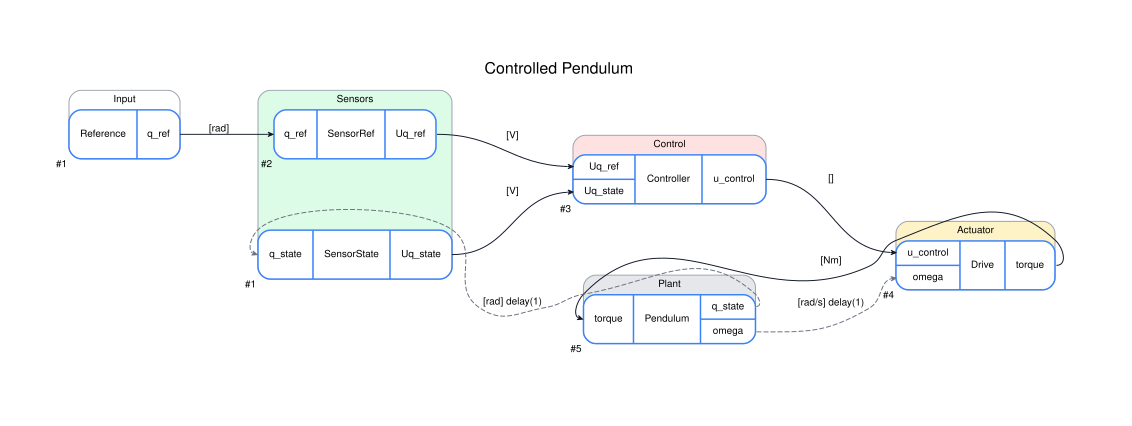

In [246]:
from graphviz import Digraph

fontsize = 10

dot = Digraph(
    name=system.name,
    comment="Controlled Pendulum System",
    filename="controlled_pendulum_system.gv",
    format="svg",
    engine="dot",
    graph_attr={
        "rankdir": "LR",
        "splines": "true",
        "pad": "0.75",
        "nodesep": "1",
        "ranksep": "0.75",
        "esep": "0",
        "sep": "0",
        "fontsize": "16",
        "fontname": "Helvetica",
        "bgcolor": "white",
        "margin": "0.2",
        "labelloc": "t",
        "label": system.name,
        "compound": "true",
        "smoothType": "graph_dist",
    },
    node_attr={
        "shape": "record",
        "style": "rounded,filled",
        "fillcolor": "white",
        "color": "#3b82f6",
        "penwidth": "1.5",
        "fontname": "Helvetica",
        "fontsize": f"{fontsize}",
        "width": "1.5",
        "height": "0.7",
        "margin": "0.12,0.1",
    },
    edge_attr={
        "arrowsize": "0.5",
        "penwidth": "1",
        "color": "#111827",
        "fontname": "Helvetica",
        "fontsize": f"{fontsize}",
        "labelfontcolor": "#374151",
        "labelangle": "45",
        "dir": "forward",
        "arrowhead": "open",
        "arrowtail": "none",
        "style": "solid",
        "minlen": "1.4",
    },
)

palette = {
    "Reference": "#dbeafe",
    "Sensors": "#dcfce7",
    "Control": "#fee2e2",
    "Actuator": "#fef3c7",
    "Plant": "#e5e7eb",
}

for group, nodes in system.groups.items():
    with dot.subgraph(name=f"cluster_{group}") as c:
        c.attr(
            label=group,
            style="rounded",
            color="#9ca3af",
            bgcolor=palette.get(group, "white"),
            fontname="Helvetica",
            fontsize=f"{fontsize}",
        )
        for mod in nodes:
            gen = generations_dict.get(mod.name, -1)
            badge = f"#{gen + 1}"
            c.node(mod.name, label=mod.label, xlabel=badge)

for conn in connections:
    label = f"[{conn.src_out_port.quantity.units:~P}]"
    if conn.delay > 0:
        label += f" delay({conn.delay})"

    src_port = f"{conn.src_out_port.name}:e"
    dst_port = f"{conn.dst_in_port.name}:w"

    edge_style = {
        "style": "dashed" if conn.delay > 0 else "solid",
        "color": "#6b7280" if conn.delay > 0 else "#111827",
    }

    dot.edge(
        tail_name=conn.src_module.name,
        head_name=conn.dst_module.name,
        label=label,
        tailport=src_port,
        headport=dst_port,
        tailclip="true",
        headclip="true",
        **edge_style,
    )

# Render without auto-opening (view=False)
dot.render(view=False)

with dot.subgraph() as same:
    same.attr(rank="same")


# Display in Jupyter
from IPython.display import SVG, display

display(SVG(filename="controlled_pendulum_system.gv.svg"))

In [247]:
def set_inputs_for_generation(generation_modules):
    """Set inputs for all modules in a specific generation"""
    for mod_name in generation_modules:
        # Find all connections where this module is the destination
        for conn in system.connections:
            if conn.dst_module.name == mod_name:
                # Get variable and value from source module
                out_var = conn.src_out_port
                out_val = system.modules[conn.src_module.name].get_output(out_var.name)

                # Set input of destination module
                system.modules[conn.dst_module.name].set_input(conn.dst_in_port.name, out_val)

                print(f" Setting {conn.dst_module.name}.{conn.dst_in_port.name} = {out_val}")


def execute_generation(generation_modules):
    """Execute all modules in a generation (these can run in parallel)"""
    print(f" Executing generation: {generation_modules}")
    for mod_name in generation_modules:
        system.modules[mod_name].do_step()
        print(f" New state of {mod_name}:")
        mod = system.modules[mod_name]
        for var in mod.inputs.values():
            print(f"    Input {var.name}: {var.quantity}")
        for var in mod.outputs.values():
            print(f"    Output {var.name}: {var.quantity}")


def simulate_step():
    """Improved simulation step respecting execution order and parallelizable groups"""
    print("Processing generations in order:")
    for gen_idx, generation in enumerate(generations):
        print(f"\n--- Generation {gen_idx + 1}: {generation} ---")

        # Step 1: Set inputs for all modules in this generation
        set_inputs_for_generation(generation)

        # Step 2: Execute all modules in this generation (parallelizable)
        execute_generation(generation)

In [248]:
for i in range(2):
    print(f"\n=================== Simulation Step {i + 1} ===================")
    simulate_step()


=================== Simulation Step 1 ===================
Processing generations in order:

--- Generation 1: ['Reference', 'SensorState'] ---
 Setting SensorState.q_state = 0 rad
 Executing generation: ['Reference', 'SensorState']
 New state of Reference:
    Output q_ref: 1 rad
 New state of SensorState:
    Input q_state: 0 rad
    Output Uq_state: 1 V

--- Generation 2: ['SensorRef'] ---
 Setting SensorRef.q_ref = 1 rad
 Executing generation: ['SensorRef']
 New state of SensorRef:
    Input q_ref: 1 rad
    Output Uq_ref: 1 V

--- Generation 3: ['Controller'] ---
 Setting Controller.Uq_ref = 1 V
 Setting Controller.Uq_state = 1 V
 Executing generation: ['Controller']
 New state of Controller:
    Input Uq_ref: 1 V
    Input Uq_state: 1 V
    Output u_control: 1

--- Generation 4: ['Drive'] ---
 Setting Drive.u_control = 1
 Setting Drive.omega = 0.0 rad/s
 Executing generation: ['Drive']
 New state of Drive:
    Input u_control: 1
    Input omega: 0.0 rad/s
    Output torque: 1 Nm
